## Commits per day!

In [75]:
import pandas as pd
import sqlite3

In [76]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

query = """
SELECT name 
FROM sqlite_master 
WHERE type='table';
"""

pd.read_sql_query(query, conn)


,name
0,pageviews
1,checker
2,deadlines


In [77]:
query="""
SELECT timestamp FROM checker WHERE uid LIKE 'user%';
"""

commit_time=pd.read_sql_query(query, conn)
commit_time

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


In [78]:
commit_time[['date', 'time']] = commit_time['timestamp'].str.split(' ', expand=True)
commit_time.head(10)

,timestamp,date,time
0,2020-04-17 05:19:02.744528,2020-04-17,05:19:02.744528
1,2020-04-17 05:22:35.249331,2020-04-17,05:22:35.249331
2,2020-04-17 05:22:45.549397,2020-04-17,05:22:45.549397
3,2020-04-17 05:34:14.691200,2020-04-17,05:34:14.691200
4,2020-04-17 05:34:24.422370,2020-04-17,05:34:24.422370
5,2020-04-17 05:43:18.546760,2020-04-17,05:43:18.546760
6,2020-04-17 05:43:27.773992,2020-04-17,05:43:27.773992
7,2020-04-17 05:46:22.151752,2020-04-17,05:46:22.151752
8,2020-04-17 05:46:32.275104,2020-04-17,05:46:32.275104
9,2020-04-17 05:50:17.757425,2020-04-17,05:50:17.757425


In [79]:
commit_time['time']=commit_time['time'].astype('datetime64[ns]')

In [80]:
# bins = [0, 4, 10, 17, 24]
# day_times=['night', 'morning', 'afternoon', 'evening']

# commit_time['daytime']=pd.cut(commit_time['time'], bins=bins, labels=day_times)

commit_time.loc[(commit_time['time'] >= '00:00:00' ) & (commit_time['time'] < '03:59:59' ),'daytime'] = 'night'
commit_time.loc[(commit_time['time'] >= '04:00:00' ) & (commit_time['time'] < '09:59:59' ),'daytime'] = 'morning'
commit_time.loc[(commit_time['time'] >= '10:00:00' ) & (commit_time['time'] < '16:59:59' ),'daytime'] = 'afternoon'
commit_time.loc[(commit_time['time'] >= '17:00:00' ) & (commit_time['time'] < '23:59:59' ),'daytime'] = 'evening'

commit_time

,timestamp,date,time,daytime
0,2020-04-17 05:19:02.744528,2020-04-17,2025-12-05 05:19:02.744528,morning
1,2020-04-17 05:22:35.249331,2020-04-17,2025-12-05 05:22:35.249331,morning
2,2020-04-17 05:22:45.549397,2020-04-17,2025-12-05 05:22:45.549397,morning
3,2020-04-17 05:34:14.691200,2020-04-17,2025-12-05 05:34:14.691200,morning
4,2020-04-17 05:34:24.422370,2020-04-17,2025-12-05 05:34:24.422370,morning
...,...,...,...,...
3202,2020-05-21 20:19:06.872761,2020-05-21,2025-12-05 20:19:06.872761,evening
3203,2020-05-21 20:22:41.785725,2020-05-21,2025-12-05 20:22:41.785725,evening
3204,2020-05-21 20:22:41.877806,2020-05-21,2025-12-05 20:22:41.877806,evening
3205,2020-05-21 20:37:00.129678,2020-05-21,2025-12-05 20:37:00.129678,evening


In [81]:
commit_time.drop(columns=['timestamp', 'time'], inplace=True)

commit_time

,date,daytime
0,2020-04-17,morning
1,2020-04-17,morning
2,2020-04-17,morning
3,2020-04-17,morning
4,2020-04-17,morning
...,...,...
3202,2020-05-21,evening
3203,2020-05-21,evening
3204,2020-05-21,evening
3205,2020-05-21,evening


<Axes: xlabel='date'>

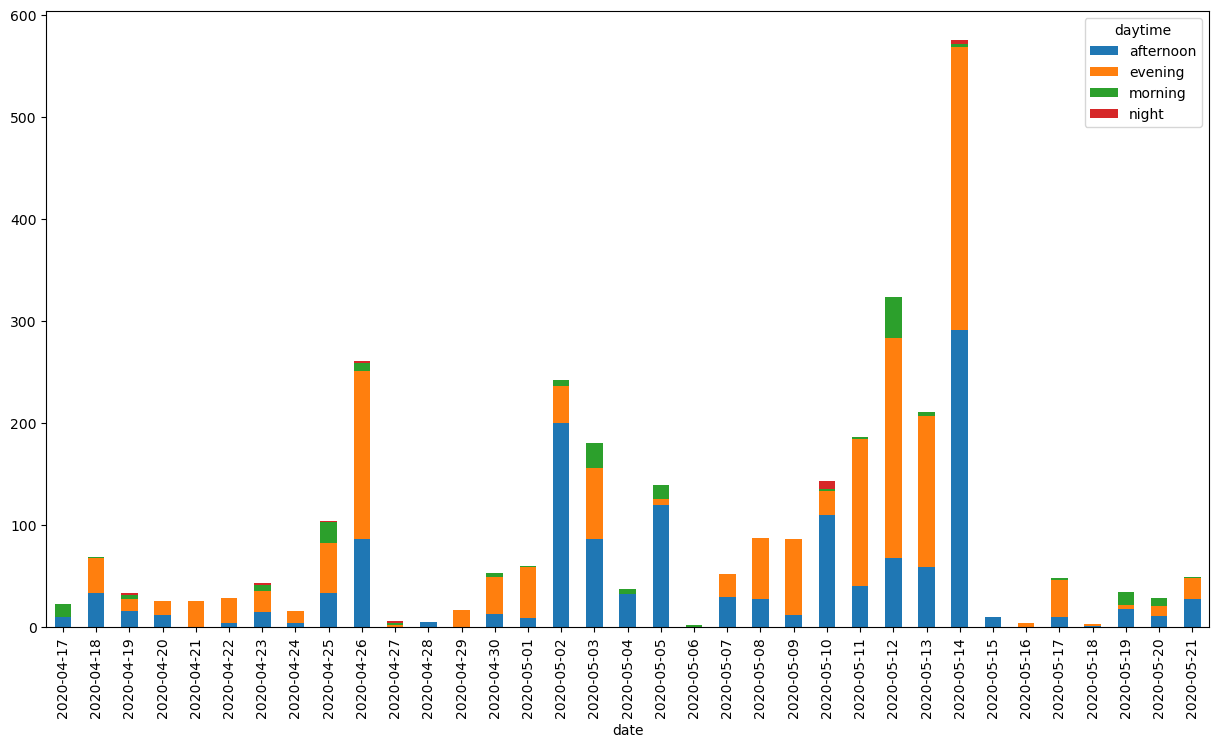

In [82]:
pivot = commit_time.groupby(['date', 'daytime']).size().unstack(fill_value=0)

pivot.plot.bar(stacked=True, figsize=(15, 8))


In [83]:
conn.close()

## Usually, students commit at evening and afternoon!
## In 2020-05-14, the most commits have been made and number of commits made at afternoon is more than evening!